In [1]:
import torch
import torch.nn as nn
import random, os
from PIL import Image

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.datasets as datasets
import torch.nn.functional as F 
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

c:\Users\ChxraWish\anaconda3\envs\nvidiaGPU_ForVoiceGenTraining\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device = cuda


In [2]:
class SynchronizedTransform:
    def __init__(self, rotation_range=15, scale_range=(1, 1.2)):
        self.rotation_range = rotation_range
        self.scale_range = scale_range

    def __call__(self, past_img, present_img):
        angle = random.uniform(0, self.rotation_range)
        scale = random.uniform(self.scale_range[0], self.scale_range[1])

        transform = transforms.Compose([
            transforms.Resize((400, 400)),
            transforms.ToTensor()
        ])

        return transform(past_img), transform(present_img)

In [3]:
class SimpleImageDataset(Dataset):
    def __init__(self, past_dir, present_dir, transform=None):
        self.past_dir = past_dir
        self.present_dir = present_dir
        self.transform = transform
        
          อ่านไฟล์ทั้งหมดจากโฟลเดอร์ Past
        past_files = [f for f in os.listdir(past_dir) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
          อ่านไฟล์ทั้งหมดจากโฟลเดอร์ Present
        present_files = [f for f in os.listdir(present_dir) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
          หาไฟล์ที่มีชื่อเหมือนกันใน 2 โฟลเดอร์
        matching_files = []
        for past_file in past_files:
            if past_file in present_files:
                matching_files.append(past_file)
        
          สร้าง pairs ของไฟล์
        self.pairs = []
        for filename in matching_files:
            past_path = os.path.join(past_dir, filename)
            present_path = os.path.join(present_dir, filename)
            
              ตรวจสอบว่าไฟล์มีอยู่จริง
            if os.path.exists(past_path) and os.path.exists(present_path):
                self.pairs.append((past_path, present_path))
        
        print(f"Found {len(self.pairs)} matching image pairs")
        if len(self.pairs) == 0:
            raise ValueError("No matching image pairs found!")
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        past_path, present_path = self.pairs[idx]
        
        past_img = Image.open(past_path).convert("RGB")
        present_img = Image.open(present_path).convert("RGB")
        
        if self.transform:
            if isinstance(self.transform, SynchronizedTransform):
                past_img, present_img = self.transform(past_img, present_img)
            else:
                past_img = self.transform(past_img)
                present_img = self.transform(present_img)
        
        return past_img, present_img
sync_transform = SynchronizedTransform(rotation_range=15, scale_range=(0.8, 1.2))
dataset = SimpleImageDataset("Present_Augmented", "Past_Augmented", transform=sync_transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

for past, present in dataloader:
    print(past.shape, present.shape)
    break


Found 760 matching image pairs
torch.Size([64, 3, 400, 400]) torch.Size([64, 3, 400, 400])


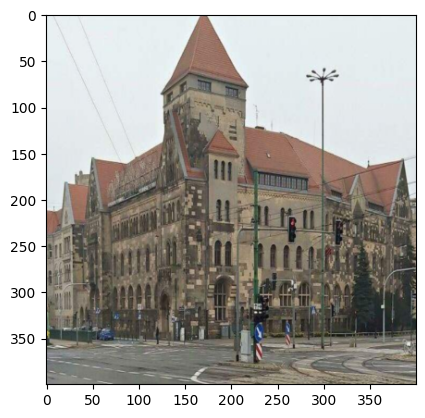

In [4]:
present, past = dataset[0]

plt.imshow(present.permute(1, 2, 0).cpu().numpy())
plt.show()

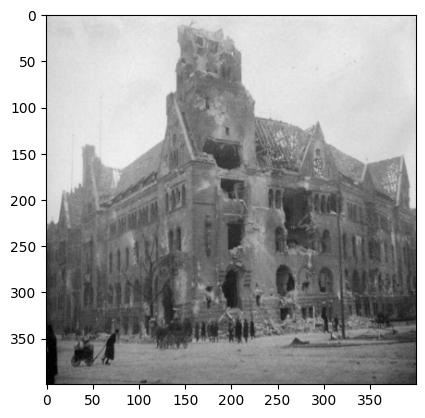

In [5]:
plt.imshow(past.permute(1, 2, 0).cpu().numpy())
plt.show()

In [6]:
class CNN_PastImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=2)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1, stride=2)

        self.conTrans1 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conTrans2 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conTrans3 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conTrans4 = nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=3, padding=1, stride=2, output_padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conTrans1(x))
        x = F.relu(self.conTrans2(x))
        x = F.relu(self.conTrans3(x))
        x = F.sigmoid(self.conTrans4(x))
        return x

model = CNN_PastImage().to(device)
  summary(model, )


In [ ]:
criterion = nn.MSELoss()


In [18]:
 1200 epoch
optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
epochs = 100
model.train()

for epoch in range(epochs):
    for present_imgs, past_imgs in dataloader:
        present_imgs = present_imgs.to(device)
        past_imgs = past_imgs.to(device)
        output = model(present_imgs)
        loss = criterion(output.to(device), past_imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

      if epoch % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
    if (epoch + 1) % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss.item(),
        }, "checkpoint.pth")
        print("Model saved")

Epoch 1/100, Loss: 0.012852608226239681
Epoch 2/100, Loss: 0.012440958991646767
Epoch 3/100, Loss: 0.012253085151314735
Epoch 4/100, Loss: 0.012258458882570267
Epoch 5/100, Loss: 0.012181167490780354
Epoch 6/100, Loss: 0.012184231542050838
Epoch 7/100, Loss: 0.012276047840714455
Epoch 8/100, Loss: 0.012226821854710579
Epoch 9/100, Loss: 0.012273639440536499
Epoch 10/100, Loss: 0.01214749738574028
Epoch 11/100, Loss: 0.012197284027934074
Epoch 12/100, Loss: 0.012196916155517101
Epoch 13/100, Loss: 0.01226057205349207
Epoch 14/100, Loss: 0.012264365330338478
Epoch 15/100, Loss: 0.012198206968605518
Epoch 16/100, Loss: 0.012191436253488064
Epoch 17/100, Loss: 0.012265857309103012
Epoch 18/100, Loss: 0.012318262830376625
Epoch 19/100, Loss: 0.012381622567772865
Epoch 20/100, Loss: 0.012084433808922768
Epoch 21/100, Loss: 0.01218931470066309
Epoch 22/100, Loss: 0.01222279854118824
Epoch 23/100, Loss: 0.01232139766216278
Epoch 24/100, Loss: 0.012093591503798962
Epoch 25/100, Loss: 0.01213509

torch.Size([64, 3, 400, 400])


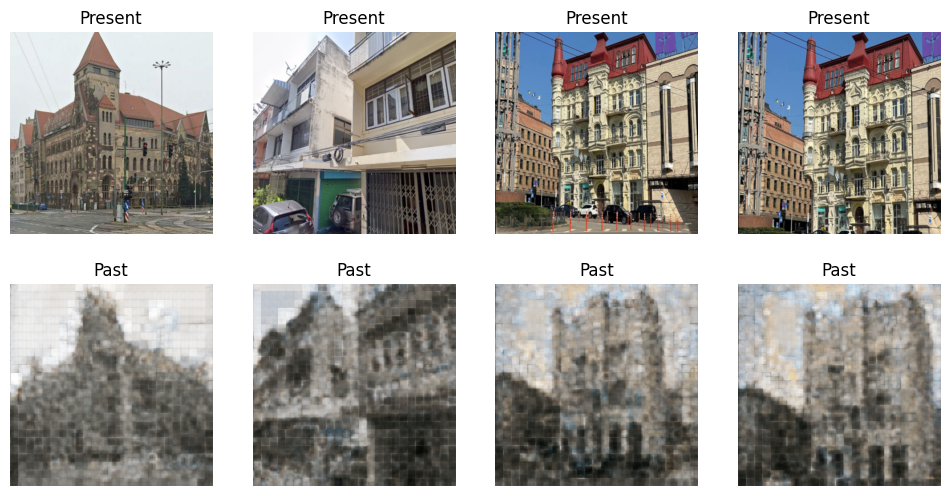

In [19]:
imags, _ = next(iter(dataloader))

model.eval()
with torch.no_grad():
    output = model(imags.to(device))
print(output.shape)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    input_image = imags[i].permute(1, 2, 0).cpu().numpy()
    output_image = output[i].permute(1, 2, 0).cpu().numpy()

    input_image = np.clip(input_image, 0, 1)
    output_image = np.clip(output_image, 0, 1)
    axes[0, i].imshow(input_image)
    axes[0, i].set_title('Present')
    axes[0, i].axis('off')

    axes[1, i].imshow(output_image)
    axes[1, i].set_title('Past')
    axes[1, i].axis('off')

In [9]:
  Load model checkpoint to resume training
checkpoint = torch.load('checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Resuming training from epoch {start_epoch+1} with loss {loss}")

Resuming training from epoch 400 with loss 0.017857186496257782
